# In This notebook i will be showcasing my work of python matplotlib 
### In this work i will be using kaggle dataset named students_dataset_10000_rows.csv 
---

In [61]:
#Lets include neccessary lib first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
# Lets use this data now:
data = pd.read_csv('student_dataset_10000_rows.csv')

In [63]:
data.info

<bound method DataFrame.info of       study_hours  attendance  sleep_hours  internet_usage  \
0               7          56            8               7   
1               4          69            5               3   
2              11          60            7               6   
3               8          99            9               8   
4               5          52            8               6   
...           ...         ...          ...             ...   
9995            2          58            9               7   
9996            7          98            6               9   
9997           10          44            8               5   
9998           10          75            7               5   
9999            2          70            6              11   

      assignments_completed  previous_score  exam_score placement_status  
0                        10              62      100.00           Placed  
1                         8              56      100.00           Placed 

In [64]:
data.columns


Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='str')

In [65]:
data.describe()
data.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

### In This data there are no null value we dont need to preprocess it
--- 



### Lets move towards plots
Lets Try for scatterplots :


Does studying more lead to higher exam scores?

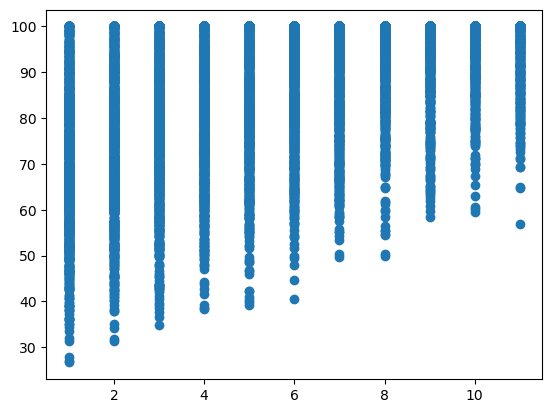

In [66]:
plt.scatter(data=data,x = 'study_hours',y = 'exam_score') #will help us to know about relationship btw studyhours and exam scores

From this plot we cant actually comment some stuff but we see as nu,ber hours increase tendency to get low scores decreases


Does attendance correlate with exam performance?

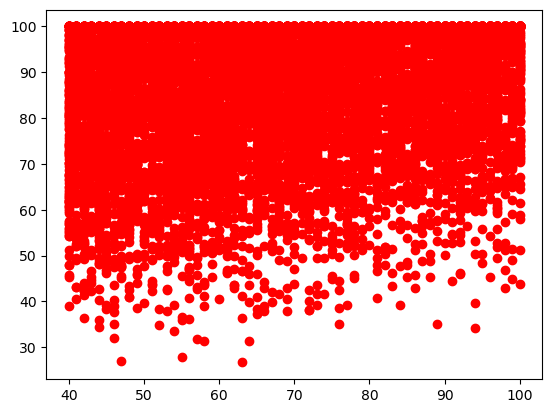

In [67]:
plt.scatter(data = data, x = 'attendance', y = 'exam_score',color= 'red')

So above mentioned red colour plot signify if more the attendance lesser chances of getting low scores


Is there a relationship between sleep hours and exam scores?

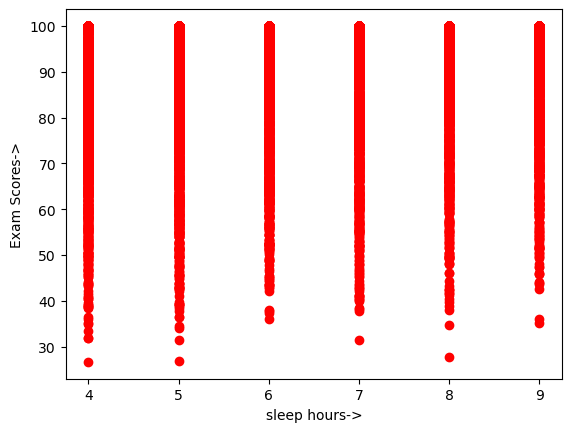

In [68]:
plt.scatter(data = data, x = 'sleep_hours', y = 'exam_score',color= 'red')
plt.xlabel('sleep hours->')
plt.ylabel('Exam Scores->')
plt.show()

From this we cant comment fully relation of sleep with exam scores

---
## Now lets try for Histograms:

### What is the distribution of exam scores? 

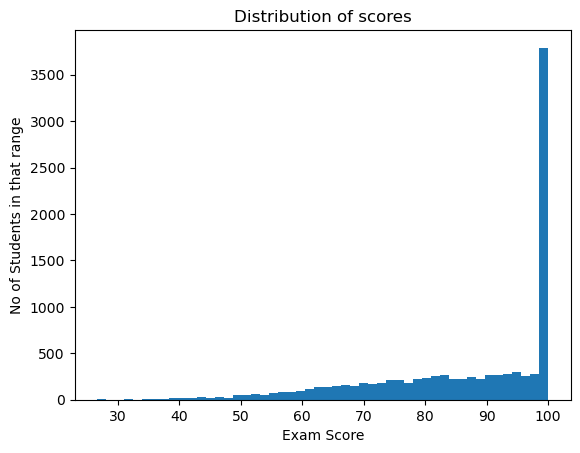

In [69]:
plt.hist(data = data, x= 'exam_score',bins = 50)
plt.xlabel('Exam Score')
plt.ylabel('No of Students in that range')
plt.title('Distribution of scores')
plt.show()

From this , 50 bins have we observe a major faction of marks is generated in 95 above fraction , after that from 95 to 30 we observe a downward trend

### How are attendance percentages distributed?


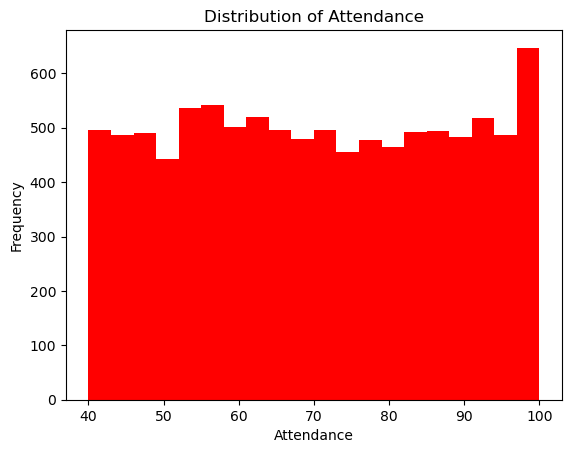

In [70]:
plt.hist(data['attendance'], bins=20, color='red')
plt.xlabel('Attendance')
plt.ylabel('Frequency')
plt.title('Distribution of Attendance')
plt.show()

In this data, there is very ungeneralised trend of attendence, we have all fractions of students at list

### What is the distribution of study hours among students?

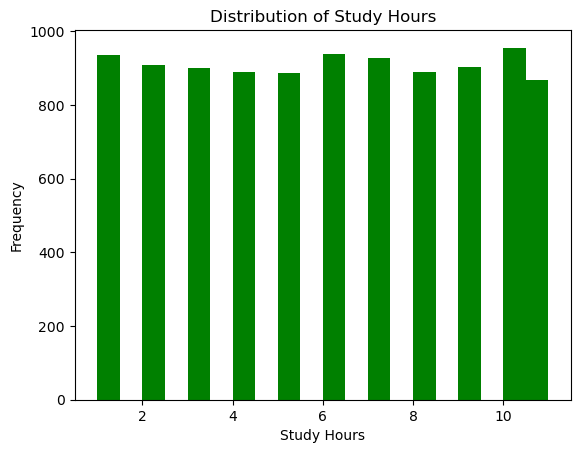

In [71]:
plt.hist(data['study_hours'], bins=20, color='green')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Study Hours')
plt.show()

---
## Box Plots
under this we will be dealing with Box Plots
### Do placed students score higher then non-placed?
for this question we will be using boxplots to compare

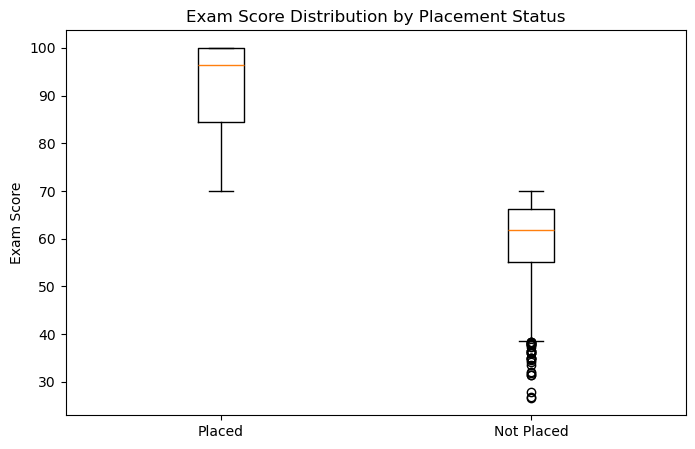

In [72]:
placed = data[data['placement_status'] == 'Placed']['exam_score']
not_placed = data[data['placement_status'] == 'Not Placed']['exam_score']

plt.figure(figsize=(8,5))

plt.boxplot([placed, not_placed])

plt.xticks([1, 2], ['Placed', 'Not Placed'])
plt.ylabel('Exam Score')
plt.title('Exam Score Distribution by Placement Status')

plt.show()

from this boxplot we can see, that data has mean of somewhat 96score who are placed and min of 70.

so Yes Marks and placements are associated with each other

### How do study hours differ between placed and non-placed students?


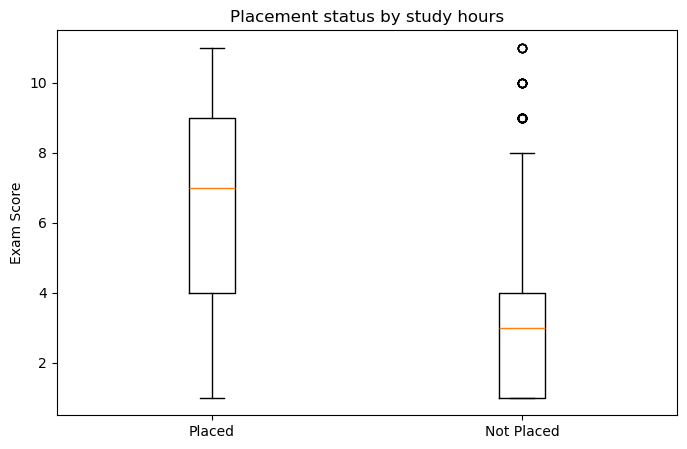

In [73]:
# for this we will again plot a boxplot
placed = data[data['placement_status'] == 'Placed']['study_hours']
not_placed = data[data['placement_status'] == 'Not Placed']["study_hours"]

plt.figure(figsize=(8,5))

plt.boxplot([placed, not_placed])

plt.xticks([1, 2], ['Placed', 'Not Placed'])
plt.ylabel('Exam Score')
plt.title('Placement status by study hours')

plt.show()

from this pot we can clearily see that realtion of study hours placement is imp but not that much as of exam scores

---
## Bar Charts

Here we will be using some good examples of uses of bar charts:

### What is avg exam score for each placemnet category

in this we have two placement categories "placed" "non placed"

we will differentiate data on the baises if placement for our ease

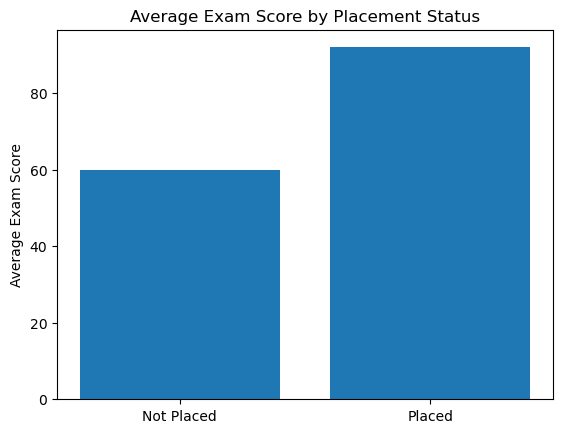

In [74]:
diffdata = data.groupby("placement_status")["exam_score"].mean()
plt.bar(diffdata.index, diffdata.values)

plt.ylabel('Average Exam Score')
plt.title('Average Exam Score by Placement Status')

plt.show()

From this we can get that, exam score and placement status correlates

### Which group has the highest average attendance?

In [75]:
placedata = data.groupby("placement_status")["attendance"].mean()

scoredata = data.groupby("exam_score")["attendance"].mean()

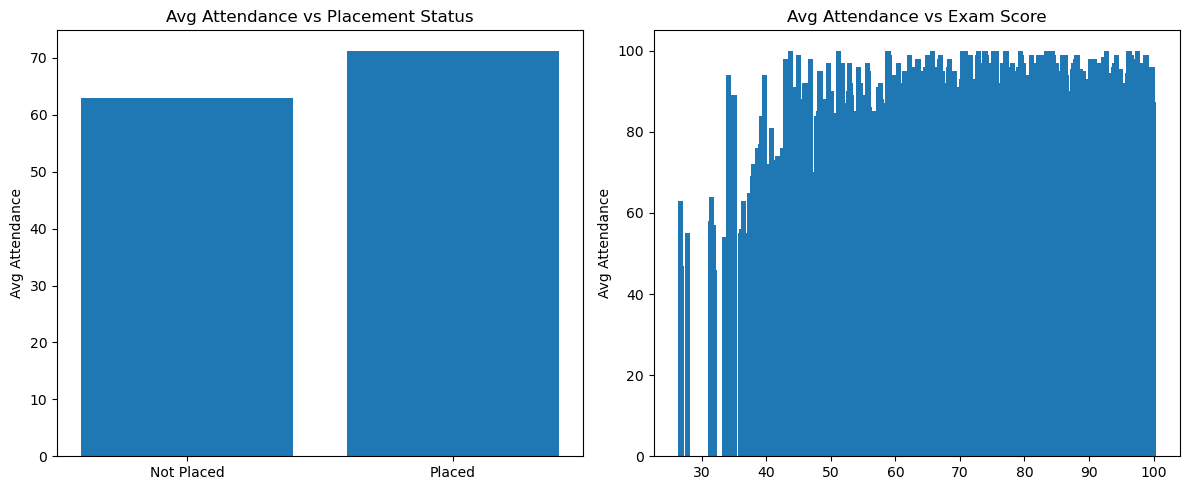

In [78]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(placedata.index, placedata.values)

plt.ylabel("Avg Attendance")
plt.title("Avg Attendance vs Placement Status")

plt.subplot(1,2,2)
plt.bar(scoredata.index, scoredata.values)

plt.ylabel("Avg Attendance")
plt.title("Avg Attendance vs Exam Score")

plt.tight_layout()
plt.show()